In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from jjmodel.input_ import p, a, inp
from jjmodel.mwdisk import local_run
from helpers import (IMFHandler, SFRHandler, PopHandler, 
    HessConstructor, ParHandler, IFMRHandler, MSAgeHandler, extract_model_tables)  
from prior import prior


Parameter file(s) : ok.
Number of parameters =  66 , among them technical =  7

 p(run_mode=0, out_dir='new_metgrid', out_mode=1, nprocess=4, Rsun=8.275, zsun=20, zmax=2000, dz=5, sigmad=29.3, sigmat=4.9, sigmag1=2.0, sigmag2=11.0, sigmadh=51.9, sigmash=0.47, td1=0, td2=7.8, dzeta=0.8, eta=5.6, pkey=1, tt1=0.1, tt2=4, gamma=2, beta=3.5, imfkey=0, a0=1.31, a1=1.5, a2=2.88, a3=2.28, m0=0.49, m1=1.43, m2=6.0, dFeHdt=0, n_FeHdt=1, fehkey=0, FeHd0=-0.7, FeHdp=0.29, rd=0.34, q=-0.72, FeHt0=-0.94, FeHtp=0.04, rt=0.77, t0=0.97, FeHsh=-1.5, dFeHsh=0.4, n_FeHsh=5, alpha=0.375, sige=26.0, sigt=45, sigdh=140, sigsh=100, sigmap=array([3.5, 1.3]), tpk=array([10. , 12.5]), dtp=array([0.7 , 0.25]), sigp=array([26.3, 12.6]))

Parameters checked: 0 Reminders, 0 Warnings, 0 Errors.

Configuration finished:  0h 0m 0.0s


## Model Hess diagram for a set of model parameters

In [2]:
mode_iso = 'Padova'
mode = 'ms+wd'
radius = 50  # pc
mag_range = [[-0.4,1.65],[-1,18]]
mag_step = [0.02,0.2]
mag_smooth = [0.06,0.8]

age_ms_param_file = 'MS_lifetime_padova_new_metgrid/analysis/'+\
                    'fit_v1_Mbr1.18/tau_ms_params_v1_Mbr1.18.txt' # Parameters for MS lifetime fits

# Volume completeness data
d_mg_lim = np.loadtxt('completeness/gdr3_dlim_vs_MG.txt').T
vz_grid = np.loadtxt('completeness/vz_grid_myvolume.txt').T

if mode == 'ms+wd':
    hess_ref = np.loadtxt('data/hess/hess_tot.txt')
elif mode == 'ms':
    hess_ref = np.loadtxt('data/hess/hess_ms.txt')
    #hess_ref = hess_ref[45:,:] # for M-dwarfs from M_G = [8,18]
else:
    hess_ref = np.loadtxt('data/hess/hess_wd.txt')


In [ ]:
ifmr_handler = IFMRHandler()
msage_handler = MSAgeHandler(param_file=age_ms_param_file)
imf_handler = IMFHandler(p)
sfr_handler = SFRHandler(p, a, inp)
pop_handler = PopHandler(p, a, inp)
constructor = HessConstructor(p, a, r_max=radius)

SFR_ref = sfr_handler.create_reference_sfr()
imf_ref, (mass_binsc, IMF_ref) = imf_handler.create_reference_imf()

mode_pop = mode
if mode != 'ms':
    if mode == 'ms+wd':
        mode_pop = 'tot'
    pop_tabs_ref = pop_handler.create_reference_pop_tabs(imf_ref,mode_iso,FeH_scatter=0.07,Nmet_dt=7,wd=mode)
    pop_tabs_ref = pop_handler.create_reference_columns(pop_tabs_ref,['N', 'Mini', 'age', 'age_WD'])
else:
    if mode == 'ms+wd':
        mode_pop = 'tot'
    pop_tabs_ref = pop_handler.create_reference_pop_tabs(imf_ref,mode_iso,FeH_scatter=0.07,Nmet_dt=7)
    pop_tabs_ref = pop_handler.create_reference_columns(pop_tabs_ref,['N', 'Mini', 'age'])

indt, indm = pop_handler.get_age_mass_idx(pop_tabs_ref,mass_binsc)

# Define DA/DB WD indices
ind_wd = pop_handler.make_wd_idx_dict(pop_tabs_ref)
if mode == 'ms+wd':
    idx_wd, idx_ms = pop_handler.separate_wd_ms_idx(pop_tabs_ref,ind_wd)
else:
    idx_wd, idx_ms = None, None



Stellar population synthesis for R = 8.275 kpc:
Warning. Some of modeled metallicities (halo) are outside of Padova metallicity range [-2.2,0.5], i.e., the adopted best isochrones may be not representative.
	thin disk	thick disk	halo


In [ ]:
idx_pop = pop_handler.split_into_pops(pop_tabs_ref)

In [4]:

vz_mag = pop_handler.get_vz_mag(pop_tabs_ref, d_mg_lim, vz_grid)


In [6]:
vz_mag['d'].shape
10**3.85

7079.457843841381

In [6]:
# Choose parameters
# ------------------------------------------
par_optim = {
#    'ifmr':         ['m_br1', 'm_br2',q 'alpha1', 'alpha2', 'alpha3'], 
#    'ifmr':         ['alpha1'], 
#    'dcool':        ['alpha_cool'],
#    'f_dadb':       ['f_da'],
    'sfr': {'d':    ['dzeta','eta','td2','sigmad'], # ,'sigmap0','tpk0'
#            't':    ['gamma','beta','tt1']
},
    'imf':          ['a0', 'a1', 'a2', 'm0', 'm1']  
}

par_handler = ParHandler(par_optim,prior)
labels = par_handler.get_flat_param_list()
params_mean, params_sigma = par_handler.get_prior_for_params()


In [7]:
# Default model
params = params_mean

# Test 0
#params = [1.001,  4.885,  9.55 , 29.121,  0.864,  1.549,  2.969,  0.515, 1.394]
#params = [0.863,  5.395,  8.185, 29.875,  0.795,  1.694,  2.956,  0.452, 1.407]
#params = [0.868, 5.349, 8.245, 0.797, 1.692, 2.998, 0.452, 1.42]

# Test 1
#params = [2.799, 3.644, 0.122, 0.174, 0.089, 0.127, 0.792]

# Test 2
#params = [0.112, 0.118, 1.256, 5.688, 7.583, 3.57 , 9.944, 1.936, 3.374,
#          0.105, 0.844, 1.717, 2.667, 0.481, 1.409] # a
#params = [0.111, 0.127, 1.272, 5.73 , 7.647, 3.634, 9.947, 1.996, 3.301,
#          0.103, 0.846, 1.78 , 2.615, 0.482, 1.393] # a, b
#params = [0.112, 0.129, 1.274, 5.685, 7.619, 3.65 , 9.947, 2.033, 3.348,
#          0.1  , 0.84 , 1.776, 2.618, 0.483, 1.404] # a, b, c
#params = [0.111,  0.06 ,  0.79 , 0.919,  4.381,  8.824, 27.911,  0.692,
#          1.796,  2.837,  0.455,  1.419] #   

# Test 3
#params = [1.087,  4.868,  7.944,  6.028, 11.367,  1.954,  3.379,  0.101,
#          0.781,  2.548,  1.735,  0.394,  1.511]

# Test 4 (SFR, IMF from wd - as Test 0 for ms)
#params = [1.064, 3.845, 9.151, 1.78 , 2.379, 3.033, 0.365, 1.383]
#params = [ 1.109,  3.406,  9.21 , 21.023]

# Custom (new SFR, default IMF)
#params = [2.9, 5.0, 10.8, 0.5, 10.0, 1.5, 1.5, 0.1]


param_struct = par_handler.fill_param_struct(params)

# Prepare parameters for posterior calculation
pop_kwargs = par_handler.prepare_posterior_kwargs(SFR_ref,IMF_ref,indt,indm,
                                                    mode_pop=mode_pop,ind_wd=ind_wd,
                                                    ind_mswd = (idx_ms,idx_wd),
                                                    f_da_teff=False,
                                                    ifmr_handler=ifmr_handler,
                                                    msage_handler=msage_handler
                                                    )

if 'sfr' in param_struct.keys():
    inp, SFR_new = sfr_handler.update_sfr(**param_struct['sfr'])
    pop_kwargs['SFR_new'] = SFR_new
    #print(SFR_new['d']/SFR_ref['d'])

if 'imf' in param_struct.keys():
    _, (_, IMF_new) = imf_handler.update_imf(**param_struct['imf'])
    pop_kwargs['IMF_new'] = IMF_new

out = local_run(p,a,inp,save=False,status_progress=False)
inp_tabs = extract_model_tables(out,inp)

pop_tabs, indt = pop_handler.update_pop_tabs(param_struct,pop_tabs_ref,**pop_kwargs)

In [8]:
pop_tabs_nz = constructor.pops_in_slice(pop_tabs,indt['d'],inp_tabs,vz_mag)

In [9]:
print(sum(pop_tabs_nz['d']['Nz']),
      sum(pop_tabs_nz['t']['Nz']),
      sum(pop_tabs_nz['sh']['Nz']),
          sum(pop_tabs_nz['d']['Nz']) + sum(pop_tabs_nz['t']['Nz']) + sum(pop_tabs_nz['sh']['Nz'])
      )

198440.4809995082 5559.99501979476 172.00966269975618 204172.48568200273


Text(0, 0.5, 'NSFR')

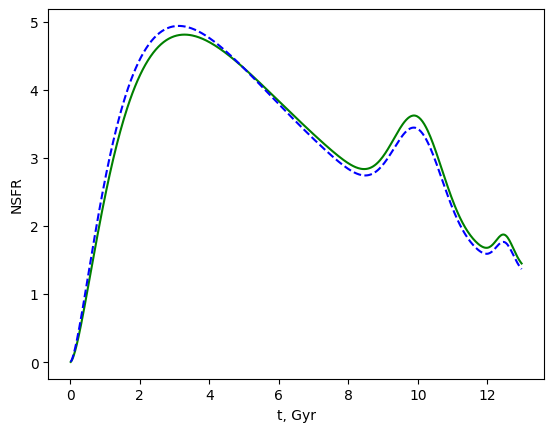

In [10]:
#plt.plot(a.t[:a.jt],SFR_new['t'], c='orange')
plt.plot(a.t,SFR_new['d'],c='g')
plt.plot(a.t,SFR_ref['d'],c='b',ls='--')
#plt.plot(a.t[:a.jt],SFR_ref['t'],c='brown',ls='--')
plt.xlabel('t, Gyr')
plt.ylabel('NSFR')
#plt.savefig('SFR_Test2.png')


In [11]:
shift = 0

hess = constructor.generate_hess(
    pop_tabs,indt['d'],inp_tabs,
    mag_range,mag_step,mag_smooth,
    color_shift=shift,
    volume='slice',
    vz_mag=vz_mag
    )

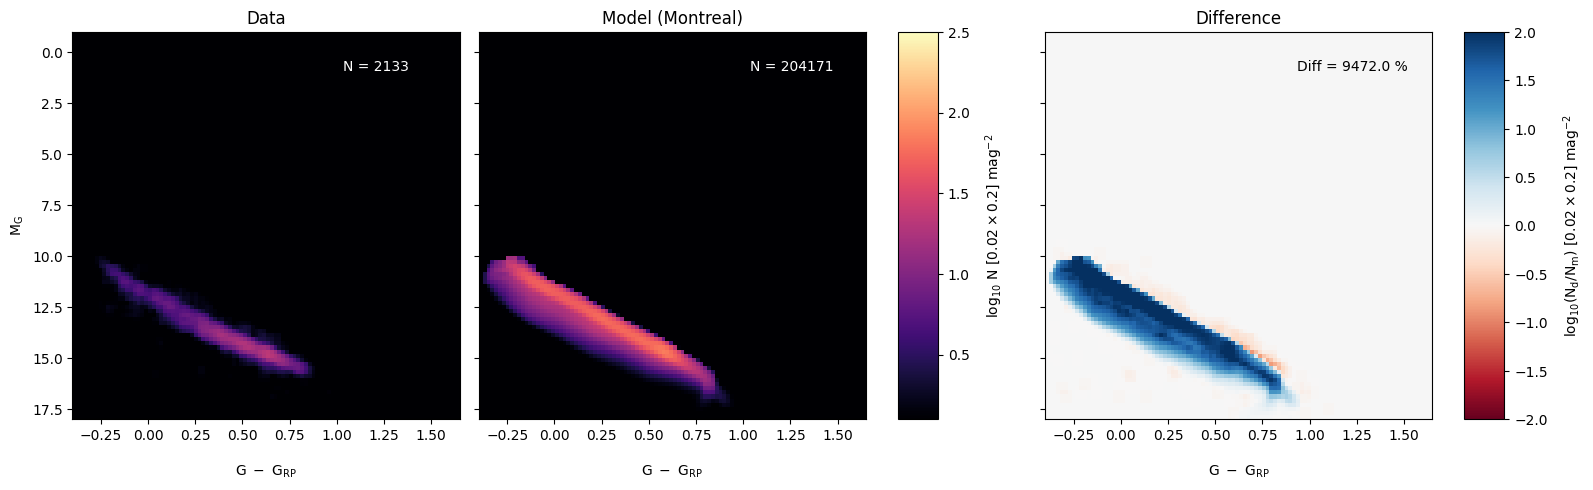

In [12]:
Ntot_d = int(round(sum(sum(hess_ref)),0))
Ntot_m = int(round(sum(sum(hess)),0))

fig, ax = plt.subplots(1,3,figsize=(16,5.5),sharey=True)

# Data
im1 = ax[0].imshow(np.log10(hess_ref+1),interpolation=None,cmap=mpl.colormaps['magma'],
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=0.1,vmax=2.5)
ax[0].text(0.7,0.9,'N = '+str(Ntot_d),color='w',transform=ax[0].transAxes)
ax[0].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[0].set_title('Data')
ax[0].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)
ax[0].set_ylabel(r'$\mathrm{M_G}$')

# Model
ax[1].imshow(np.log10(hess+1),interpolation=None,cmap=mpl.colormaps['magma'],
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=0.1,vmax=4.5)
ax[1].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[1].text(0.7,0.9,'N = '+str(Ntot_m),color='w',transform=ax[1].transAxes)
#ax[1].set_title('Model (' + mode_iso + ')')['d']
ax[1].set_title('Model (Montreal)')
ax[1].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)


fig.subplots_adjust(left=0.05,wspace=0.05,right=0.8,top=0.93)
pos = ax[1].get_position()
cax = fig.add_axes([pos.x0+pos.width+0.02,pos.y0,0.025,pos.height])
cbar = fig.colorbar(im1,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{log_{10} \ N \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10)

# Difference
diff = (np.log10(hess+1) - np.log10(hess_ref+1))#/(hess + 1)

pos_x2 = ax[2].get_position()
ax[2].set_position([pos_x2.x0+0.1,pos_x2.y0,pos_x2.width,pos_x2.height])

im2 = ax[2].imshow(diff,interpolation=None,cmap=mpl.colormaps['RdBu'],
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=-2.0,vmax=2.0)
ax[2].text(0.65,0.9,'Diff = '+str(np.round(100*(Ntot_m-Ntot_d)/Ntot_d,1))+' %',
           color='k',transform=ax[2].transAxes)
ax[2].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[2].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)
ax[2].set_title('Difference')

pos2_new = ax[2].get_position()
cax = fig.add_axes([pos2_new.x0+pos2_new.width+0.02,pos2_new.y0,0.025,pos2_new.height])
cbar = fig.colorbar(im2,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{log_{10}(N_{d}/N_{m}) \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10)

#plt.savefig('m2d_montreal_newmet_' + mode_iso + '_' + mode + '_sf' + str(shift) + '_wdms3.png')
#plt.savefig('m2d_montreal_newmet_' + mode + '_sf' + str(shift) + '.png')
#plt.savefig('CMD_Test2wd.png')


In [14]:
Ntot_m

7541143

In [15]:
# Save predictions for default model

'''
if mode == 'ms':
    np.savetxt('output/hess_m2d/padova/hess_ms.txt', hess)
elif mode == 'wd':
    np.savetxt('output/hess_m2d/padova/hess_wd.txt', hess)
else:
    np.savetxt('output/hess_m2d/padova/hess_tot.txt', hess)
''';